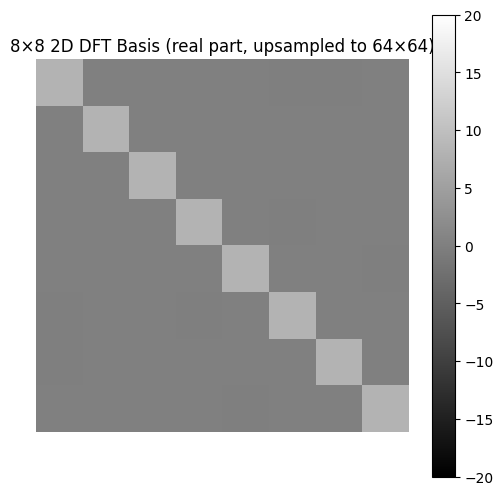

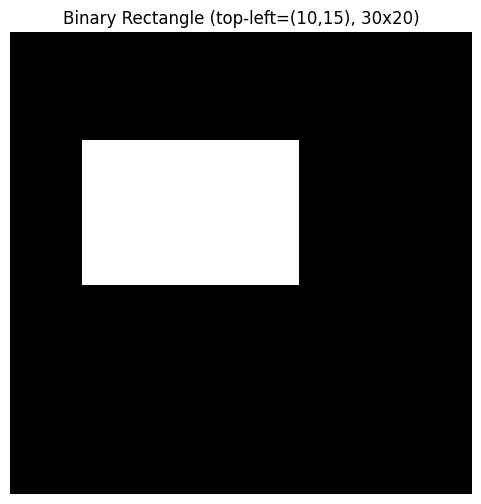

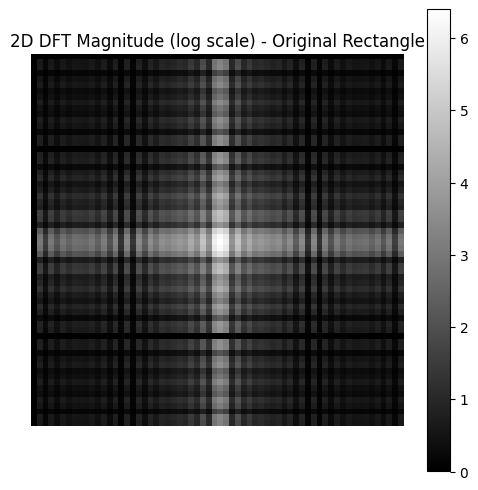

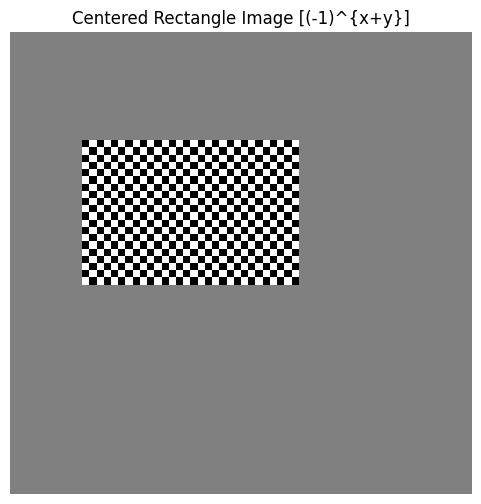

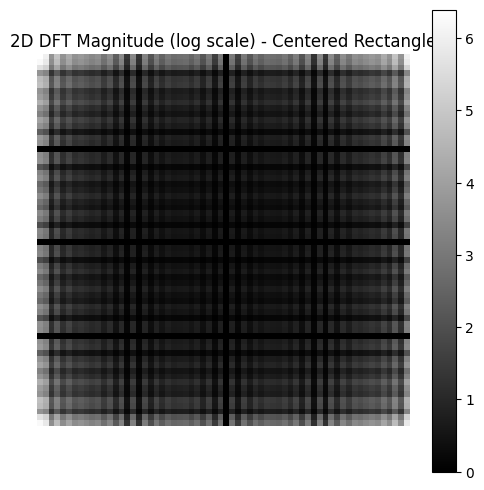

All steps completed!
Note: DFT computation is O(N^4)=64^4 ~16M operations, takes ~10-30s depending on machine.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: 8x8 2D DFT basis as 64x64 image
def dft1_matrix(N):
    """1D DFT matrix W where W[k,n] = exp(-2j*pi*k*n/N)"""
    n = np.arange(N)
    k = n.reshape((N, 1))
    return np.exp(-2j * np.pi * k * n / N)

N = 8
F1 = dft1_matrix(N)  # 1D DFT matrix
F2 = F1.T.conj()     # Hermitian for rows -> F2 = F1^H

basis_8x8 = F2 @ F1  # 2D DFT basis matrix F

# Upsample to 64x64 by zero-padding + repeat
basis_64 = np.kron(basis_8x8.real, np.ones((8,8)))  # Use real part for visualization

plt.figure(figsize=(6,6))
plt.imshow(basis_64, cmap='gray', vmin=-20, vmax=20)
plt.title('8×8 2D DFT Basis (real part, upsampled to 64×64)')
plt.colorbar()
plt.axis('off')
plt.show()

# Step 2: Binary 64x64 rectangle image
sz = 64
img = np.zeros((sz, sz))

# Take inputs (modify these values as needed)
x0, y0 = 10, 15   # top-left (row, col)
width, height = 30, 20

img[y0:y0+height, x0:x0+width] = 1

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title(f'Binary Rectangle (top-left=({x0},{y0}), {width}x{height})')
plt.axis('off')
plt.show()

# Step 3: 2D DFT of original image (MANUAL, no fft2/ifft2)
def dft2d_manual(X):
    M, N = X.shape
    F = np.zeros((M, N), dtype=complex)
    for u in range(M):
        for v in range(N):
            sum_val = 0j
            for x in range(M):
                for y in range(N):
                    sum_val += X[x, y] * np.exp(-2j * np.pi * (u*x / M + v*y / N))
            F[u, v] = sum_val
    return F

F_original = dft2d_manual(img)

# Log magnitude plot (shifted for DC center)
log_mag_orig = np.log(np.abs(np.fft.fftshift(F_original)) + 1)
plt.figure(figsize=(6,6))
plt.imshow(log_mag_orig, cmap='gray')
plt.title('2D DFT Magnitude (log scale) - Original Rectangle')
plt.colorbar()
plt.axis('off')
plt.show()

# Step 4: Centered image: multiply by (-1)^{x+y}
centered_img = img * ((-1) ** (np.arange(sz)[:,None] + np.arange(sz)[None,:]))

plt.figure(figsize=(6,6))
plt.imshow(centered_img, cmap='gray')
plt.title('Centered Rectangle Image [(-1)^{x+y}]')
plt.axis('off')
plt.show()

# 2D DFT of centered image
F_centered = dft2d_manual(centered_img)

log_mag_centered = np.log(np.abs(np.fft.fftshift(F_centered)) + 1)
plt.figure(figsize=(6,6))
plt.imshow(log_mag_centered, cmap='gray')
plt.title('2D DFT Magnitude (log scale) - Centered Rectangle')
plt.colorbar()
plt.axis('off')
plt.show()

print("All steps completed!")
print("Note: DFT computation is O(N^4)=64^4 ~16M operations, takes ~10-30s depending on machine.")